## KNN-Based Collaborative Filtering
- Memory-based recommendation approach
- Identifies K most similar users based on rating patterns
- Predicts ratings using weighted average of K nearest neighbours

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 2. Load Dataset

In [2]:
DATASET_PATH = "datasets/ml-100k/"

# Load full ratings data
full_df = pd.read_csv(
    DATASET_PATH + "u.data",
    sep="\t",
    header=None,
    usecols=[0, 1, 2],
    names=["user_id", "movie_id", "rating"]
)

print(f"Full dataset shape: {full_df.shape}")
full_df.head()

Full dataset shape: (100000, 3)


,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


### 3. User-User Similarity Distribution
Analyse the distribution of cosine similarity scores between all user pairs

Computing 385x385 user similarity matrix...
Total user pairs analysed : 73,920
Mean similarity           : 0.0399
Median similarity         : 0.0000
Pairs with sim > 0.5      : 22 (0.0%)
Pairs with sim > 0.8      : 0 (0.0%)
Pairs with sim = 0        : 39,502 (53.4%)


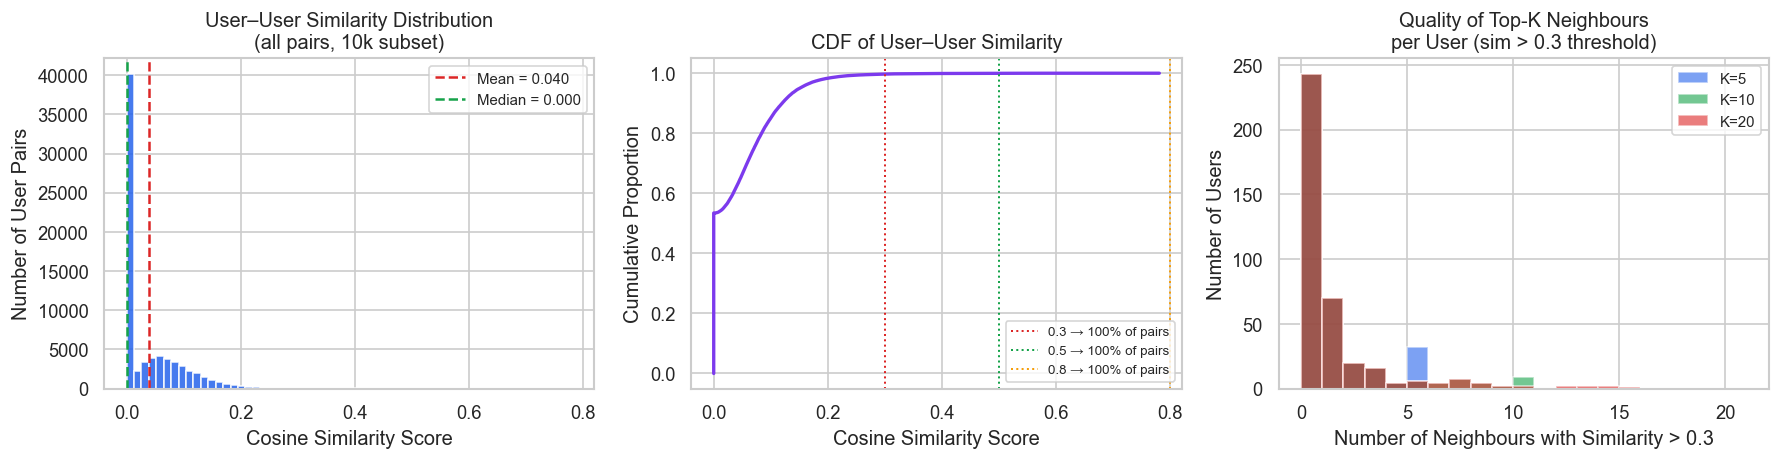

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# Use 10k subset for the similarity analysis
sample_df   = full_df.head(10000).copy()
sample_matrix = sample_df.pivot_table(
    index="user_id", columns="movie_id", values="rating"
).fillna(0)

print(f"Computing {sample_matrix.shape[0]}x{sample_matrix.shape[0]} user similarity matrix...")
sim_matrix = cosine_similarity(sample_matrix)

# Extract upper triangle only (avoid duplicate pairs and self-similarity on diagonal)
upper_idx = np.triu_indices_from(sim_matrix, k=1)
sim_scores = sim_matrix[upper_idx]

print(f"Total user pairs analysed : {len(sim_scores):,}")
print(f"Mean similarity           : {sim_scores.mean():.4f}")
print(f"Median similarity         : {np.median(sim_scores):.4f}")
print(f"Pairs with sim > 0.5      : {(sim_scores > 0.5).sum():,} ({(sim_scores > 0.5).mean()*100:.1f}%)")
print(f"Pairs with sim > 0.8      : {(sim_scores > 0.8).sum():,} ({(sim_scores > 0.8).mean()*100:.1f}%)")
print(f"Pairs with sim = 0        : {(sim_scores == 0).sum():,} ({(sim_scores == 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Full distribution
axes[0].hist(sim_scores, bins=60, color="#2563EB", edgecolor="white", alpha=0.85)
axes[0].axvline(sim_scores.mean(), color="#DC2626", linestyle="--", linewidth=1.5,
                label=f"Mean = {sim_scores.mean():.3f}")
axes[0].axvline(np.median(sim_scores), color="#16A34A", linestyle="--", linewidth=1.5,
                label=f"Median = {np.median(sim_scores):.3f}")
axes[0].set_xlabel("Cosine Similarity Score")
axes[0].set_ylabel("Number of User Pairs")
axes[0].set_title("User–User Similarity Distribution\n(all pairs, 10k subset)")
axes[0].legend(fontsize=9)

# Plot 2: Cumulative distribution
sorted_scores = np.sort(sim_scores)
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
axes[1].plot(sorted_scores, cdf, color="#7C3AED", linewidth=2)
for thresh, col in [(0.3, "#DC2626"), (0.5, "#16A34A"), (0.8, "#F59E0B")]:
    pct = (sim_scores <= thresh).mean() * 100
    axes[1].axvline(thresh, color=col, linestyle=":", linewidth=1.2,
                    label=f"{thresh} → {pct:.0f}% of pairs")
axes[1].set_xlabel("Cosine Similarity Score")
axes[1].set_ylabel("Cumulative Proportion")
axes[1].set_title("CDF of User–User Similarity")
axes[1].legend(fontsize=8)

# Plot 3: Effect of K – how many 'good' neighbours exist per user
K_thresholds = [5, 10, 20]
colors = ["#2563EB", "#16A34A", "#DC2626"]
n_users_in_sample = sample_matrix.shape[0]

for K, col in zip(K_thresholds, colors):
    # For each user, count how many of their top-K neighbours have sim > 0.3
    good_neighbour_counts = []
    for i in range(n_users_in_sample):
        row = sim_matrix[i].copy()
        row[i] = 0  # exclude self
        top_k_sims = np.sort(row)[::-1][:K]
        good_neighbour_counts.append((top_k_sims > 0.3).sum())
    axes[2].hist(good_neighbour_counts, bins=range(0, K+2), alpha=0.6,
                 label=f"K={K}", color=col, edgecolor="white")

axes[2].set_xlabel("Number of Neighbours with Similarity > 0.3")
axes[2].set_ylabel("Number of Users")
axes[2].set_title("Quality of Top-K Neighbours\nper User (sim > 0.3 threshold)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 3. Define KNN-CF Core Functions

In [4]:
def build_user_item_matrix(df):
    """Build user-item rating matrix from dataframe."""
    return df.pivot_table(index="user_id", columns="movie_id", values="rating").fillna(0)


def compute_user_similarity(user_item_matrix):
    """
    Compute cosine similarity between ALL pairs of users.
    Complexity: O(U^2 x I) where U = users, I = items.
    Returns a DataFrame with user_id as both index and columns.
    """
    similarity_matrix = cosine_similarity(user_item_matrix)
    return pd.DataFrame(
        similarity_matrix,
        index=user_item_matrix.index,
        columns=user_item_matrix.index
    )


def predict_rating_knn(user_id, movie_id, user_item_matrix, user_similarity_df, K):
    """
    Predict rating for a given (user, movie) pair using K nearest neighbours.
    Steps:
      1. Get similarity scores between target user and all other users.
      2. Keep only users who have rated the target movie.
      3. Sort by similarity and pick top-K (neighbour selection: O(U log U)).
      4. Compute weighted average rating (prediction: O(K)).
    """
    # Users who rated this movie
    movie_raters = user_item_matrix[movie_id]
    movie_raters = movie_raters[movie_raters > 0]

    if movie_raters.empty:
        return user_item_matrix.loc[user_id].replace(0, np.nan).mean()

    # Similarity of target user to those raters
    sim_scores = user_similarity_df.loc[user_id, movie_raters.index]

    # Top-K neighbours (O(U log U) sort, then slice K)
    top_k = sim_scores.sort_values(ascending=False).head(K)

    if top_k.sum() == 0:
        return user_item_matrix.loc[user_id].replace(0, np.nan).mean()

    numerator = sum(top_k[uid] * movie_raters[uid] for uid in top_k.index)
    denominator = top_k.sum()
    return numerator / denominator

### 4. Evaluate One Run
Splits each user's ratings 70/30 (train/test), hides test ratings, predicts, restores.

In [5]:
def evaluate_knn(df, K, random_state=42):
    """
    Full pipeline for one (dataset_size, K) combination.
    Returns: execution_time_ms, RMSE, MAE
    """
    # Build matrix
    user_item_matrix = build_user_item_matrix(df)

    # Compute user-user similarity (this is the expensive O(U^2 x I) step)
    user_similarity_df = compute_user_similarity(user_item_matrix)

    actual = []
    predicted = []

    start_time = time.time()

    for user_id in user_item_matrix.index:
        user_ratings = user_item_matrix.loc[user_id]
        rated = user_ratings[user_ratings > 0]

        if len(rated) < 2:
            continue  # Need at least 2 ratings to split

        train_set = rated.sample(frac=0.7, random_state=random_state)
        test_set  = rated.drop(train_set.index)

        for movie_id in test_set.index:
            true_rating = user_item_matrix.loc[user_id, movie_id]
            user_item_matrix.loc[user_id, movie_id] = 0  # hide rating

            pred = predict_rating_knn(
                user_id, movie_id,
                user_item_matrix, user_similarity_df, K
            )

            user_item_matrix.loc[user_id, movie_id] = true_rating  # restore

            actual.append(true_rating)
            predicted.append(pred)

    end_time = time.time()
    exec_time_ms = round((end_time - start_time) * 1000, 2)

    rmse = round(sqrt(mean_squared_error(actual, predicted)), 4)
    mae  = round(mean_absolute_error(actual, predicted), 4)

    return exec_time_ms, rmse, mae

### 5. Run All 6 Dataset Sizes × 3 K Values
Main experiment loop

In [6]:
SIZES   = [10000, 20000, 40000, 60000, 80000, 100000]
K_VALUES = [5, 10, 20]

results = []

for size in SIZES:
    df_subset = full_df.head(size).copy()
    print(f"\n── Dataset size: {size:,} ratings ──")

    for K in K_VALUES:
        print(f"  Running K={K}...", end=" ", flush=True)
        exec_time, rmse, mae = evaluate_knn(df_subset, K)
        print(f"Done → Time: {exec_time} ms | RMSE: {rmse} | MAE: {mae}")

        results.append({
            "Input Size": size,
            "K": K,
            "Execution Time (ms)": exec_time,
            "RMSE": rmse,
            "MAE": mae
        })

results_df = pd.DataFrame(results)


── Dataset size: 10,000 ratings ──
  Running K=5... Done → Time: 3056.3 ms | RMSE: 1.0992 | MAE: 0.8669
  Running K=10... Done → Time: 3330.8 ms | RMSE: 1.0784 | MAE: 0.8514
  Running K=20... Done → Time: 2852.91 ms | RMSE: 1.0746 | MAE: 0.8495

── Dataset size: 20,000 ratings ──
  Running K=5... Done → Time: 5516.9 ms | RMSE: 1.0565 | MAE: 0.8293
  Running K=10... Done → Time: 5484.97 ms | RMSE: 1.0311 | MAE: 0.8086
  Running K=20... Done → Time: 5484.79 ms | RMSE: 1.025 | MAE: 0.8064

── Dataset size: 40,000 ratings ──
  Running K=5... Done → Time: 11178.45 ms | RMSE: 1.0645 | MAE: 0.837
  Running K=10... Done → Time: 11272.66 ms | RMSE: 1.0373 | MAE: 0.8188
  Running K=20... Done → Time: 12273.92 ms | RMSE: 1.028 | MAE: 0.8121

── Dataset size: 60,000 ratings ──
  Running K=5... Done → Time: 16205.07 ms | RMSE: 1.0753 | MAE: 0.8468
  Running K=10... Done → Time: 20228.15 ms | RMSE: 1.0402 | MAE: 0.8207
  Running K=20... Done → Time: 20909.68 ms | RMSE: 1.0276 | MAE: 0.8126

── Data

In [7]:
results_df.head()

,Input Size,K,Execution Time (ms),RMSE,MAE
0,10000,5,3056.30,1.0992,0.8669
1,10000,10,3330.80,1.0784,0.8514
2,10000,20,2852.91,1.0746,0.8495
3,20000,5,5516.90,1.0565,0.8293
4,20000,10,5484.97,1.0311,0.8086


### 6. Results Table

In [8]:
# Pivot for cleaner viewing
pivot_time = results_df.pivot(index="Input Size", columns="K", values="Execution Time (ms)")
pivot_rmse = results_df.pivot(index="Input Size", columns="K", values="RMSE")
pivot_mae  = results_df.pivot(index="Input Size", columns="K", values="MAE")

print("Execution Time (ms):")
display(pivot_time)

print("\nRMSE:")
display(pivot_rmse)

print("\nMAE:")
display(pivot_mae)

Execution Time (ms):


K,5,10,20
Input Size,,,
10000,3056.30,3330.80,2852.91
20000,5516.90,5484.97,5484.79
40000,11178.45,11272.66,12273.92
60000,16205.07,20228.15,20909.68
80000,27200.37,28131.99,28577.82
100000,32454.92,33326.35,37467.91



RMSE:


K,5,10,20
Input Size,,,
10000,1.0992,1.0784,1.0746
20000,1.0565,1.0311,1.0250
40000,1.0645,1.0373,1.0280
60000,1.0753,1.0402,1.0276
80000,1.0553,1.0229,1.0099
100000,1.0458,1.0152,1.0022



MAE:


K,5,10,20
Input Size,,,
10000,0.8669,0.8514,0.8495
20000,0.8293,0.8086,0.8064
40000,0.8370,0.8188,0.8121
60000,0.8468,0.8207,0.8126
80000,0.8338,0.8121,0.8027
100000,0.8263,0.8047,0.7958


### 7. Graph – Input Size vs Execution Time
One graph with 3 lines (K=5, K=10, K=20) as required by the outline.

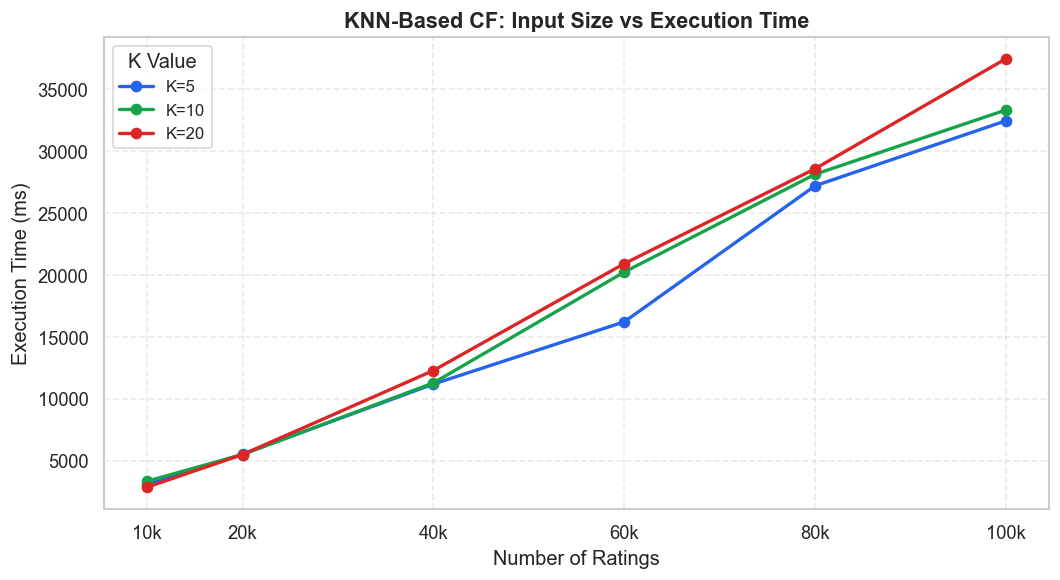

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

colors  = {5: "#2563EB", 10: "#16A34A", 20: "#DC2626"}

for K in K_VALUES:
    subset = results_df[results_df["K"] == K]
    ax.plot(
        subset["Input Size"],
        subset["Execution Time (ms)"],
        label=f"K={K}",
        color=colors[K],
        marker="o",
        linewidth=2,
        markersize=6
    )

ax.set_xlabel("Number of Ratings", fontsize=12)
ax.set_ylabel("Execution Time (ms)", fontsize=12)
ax.set_title("KNN-Based CF: Input Size vs Execution Time", fontsize=13, fontweight="bold")
ax.legend(title="K Value", fontsize=10)
ax.set_xticks(SIZES)
ax.set_xticklabels([f"{s//1000}k" for s in SIZES])
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 8. Quick Demo – Recommend Movies for One User
Shows the algorithm working end-to-end for a single user (using 10k subset, K=10).

In [10]:
# ── UPDATE THIS PATH ──
item_df = pd.read_csv(
    DATASET_PATH + "u.item",
    sep="|",
    header=None,
    encoding="latin-1",
    names=[
        "movie_id", "title", "release_date", "video_release_date",
        "IMDb_URL", "unknown", "Action", "Adventure", "Animation",
        "Children's", "Comedy", "Crime", "Documentary", "Drama", "Fantasy",
        "Film-Noir", "Horror", "Musical", "Mystery", "Romance", "Sci-Fi",
        "Thriller", "War", "Western"
    ]
)

DEMO_K = 10
demo_df = full_df.head(10000).copy()
demo_matrix = build_user_item_matrix(demo_df)
demo_sim    = compute_user_similarity(demo_matrix)

target_user = demo_matrix.index[0]  # Change to test different users

# Unrated movies for the target user
user_row    = demo_matrix.loc[target_user]
unrated     = user_row[user_row == 0].index

print(f"Predicting ratings for User {target_user} on {len(unrated)} unrated movies...")

scores = {}
for movie_id in unrated:
    scores[movie_id] = predict_rating_knn(
        target_user, movie_id, demo_matrix, demo_sim, DEMO_K
    )

# Top-10 recommendations
top10 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]

rec_list = []
for movie_id, score in top10:
    title = item_df.loc[item_df["movie_id"] == movie_id, "title"].values
    title = title[0] if len(title) > 0 else "Unknown"
    rec_list.append({"movie_id": movie_id, "title": title, "predicted_rating": round(score, 4)})

rec_df = pd.DataFrame(rec_list)
print(f"\nTop-10 Recommended Movies for User {target_user} (K={DEMO_K}):")
print(rec_df.to_string(index=False))

Predicting ratings for User 1 on 1169 unrated movies...

Top-10 Recommended Movies for User 1 (K=10):
 movie_id                                           title  predicted_rating
     1137                          Beautiful Thing (1996)               5.0
      119          Maya Lin: A Strong Clear Vision (1994)               5.0
      236                             Citizen Ruth (1996)               5.0
      280                    Up Close and Personal (1996)               5.0
      352                              Spice World (1997)               5.0
      361                                Incognito (1997)               5.0
      525                           Big Sleep, The (1946)               5.0
      538                                Anastasia (1997)               5.0
      611                                    Laura (1944)               5.0
      621 Davy Crockett, King of the Wild Frontier (1955)               5.0
